# Porównanie Etap 1 vs Etap 2 — wszystkie modele, default prompt

Etap 1: modele 4B–14B (lokalne) · Etap 2: modele 24B–32B (API) · prompt `default_pl/new_graph` · 3 artykuły

In [22]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

def short_label(m):
    if m.startswith("local:"):
        m = m[len("local:"):]
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

def load(path, etap_label):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]
    df["etap"] = etap_label
    df["model_short"] = df["model"].apply(short_label)
    df["title_short"] = df["title"].str.replace("_", " ")
    return df

df1 = load("step_1_small_models_default.csv", "Etap 1 (4B–14B)")
df2 = load("step_2_bigger_models_default.csv", "Etap 2 (24B–32B)")
df = pd.concat([df1, df2], ignore_index=True)

NUMERIC = ["precision", "recall", "t_precision", "t_recall"]

print(f"Łącznie: {len(df)} wierszy | {df['model_short'].nunique()} modeli | {df['title_short'].nunique()} artykuły")
print(f"  Etap 1: {df1['model_short'].nunique()} modeli")
print(f"  Etap 2: {df2['model_short'].nunique()} modeli")

Łącznie: 36 wierszy | 12 modeli | 3 artykuły
  Etap 1: 6 modeli
  Etap 2: 6 modeli


## Średnie per model (posortowane po T-Precision)

In [23]:
summary = (
    df.groupby(["model_short", "etap"])[NUMERIC]
    .mean()
    .round(3)
    .reset_index()
)

ETAP_COLORS = {
    "Etap 1 (4B–14B)": "#ddeeff",
    "Etap 2 (24B–32B)": "#ffeedd",
}

def color_etap(row):
    key = row.get("Etap", row.get("etap", ""))
    color = ETAP_COLORS.get(key, "")
    return [f"background-color: {color}" for _ in row]

legend_html = """
<div style='font-size:13px;margin-bottom:8px'>
  <span style='background:#ddeeff;padding:3px 8px;border-radius:3px'>Etap 1 (4B–14B)</span>&nbsp;&nbsp;
  <span style='background:#ffeedd;padding:3px 8px;border-radius:3px'>Etap 2 (24B–32B)</span>
</div>
"""

for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>" + legend_html))
    styled = (
        summary.sort_values(sort_col, ascending=False)
        .rename(columns={"model_short": "Model", "etap": "Etap",
                         "precision": "Prec.", "recall": "Recall",
                         "t_precision": "T-Prec.", "t_recall": "T-Recall"})
        .style
        .apply(color_etap, axis=1)
        .background_gradient(subset=["Prec.", "Recall", "T-Prec.", "T-Recall"], cmap="RdYlGn", vmin=0, vmax=1)
        .format({"Prec.": "{:.1%}", "Recall": "{:.1%}", "T-Prec.": "{:.1%}", "T-Recall": "{:.1%}"})
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )
    display(styled)

Model,Etap,Prec.,Recall,T-Prec.,T-Recall
nemotron-3-nano-30b-a3b,Etap 2 (24B–32B),100.0%,38.4%,90.5%,14.6%
gemma-4-31b-it,Etap 2 (24B–32B),97.0%,70.1%,94.1%,49.6%
bielik-11b-v3.0-instruct,Etap 1 (4B–14B),94.9%,47.8%,85.2%,23.4%
mistral-7b-instruct-v0.3,Etap 1 (4B–14B),94.2%,44.5%,60.8%,15.0%
mistral-small-3.2-24b-instruct,Etap 2 (24B–32B),91.9%,69.1%,86.0%,63.1%
gemma-4-26b-a4b-it,Etap 2 (24B–32B),91.0%,66.1%,89.7%,51.6%
qwen3-30b-a3b-instruct-2507,Etap 2 (24B–32B),88.7%,60.6%,78.7%,44.9%
qwen3-vl-8b,Etap 1 (4B–14B),88.0%,56.8%,79.5%,41.7%
qwen3-14b,Etap 1 (4B–14B),81.6%,60.6%,82.3%,49.8%
qwen3-32b,Etap 2 (24B–32B),79.4%,58.7%,78.9%,48.2%


Model,Etap,Prec.,Recall,T-Prec.,T-Recall
gemma-4-31b-it,Etap 2 (24B–32B),97.0%,70.1%,94.1%,49.6%
nemotron-3-nano-30b-a3b,Etap 2 (24B–32B),100.0%,38.4%,90.5%,14.6%
gemma-4-26b-a4b-it,Etap 2 (24B–32B),91.0%,66.1%,89.7%,51.6%
mistral-small-3.2-24b-instruct,Etap 2 (24B–32B),91.9%,69.1%,86.0%,63.1%
bielik-11b-v3.0-instruct,Etap 1 (4B–14B),94.9%,47.8%,85.2%,23.4%
qwen3-14b,Etap 1 (4B–14B),81.6%,60.6%,82.3%,49.8%
qwen3-vl-8b,Etap 1 (4B–14B),88.0%,56.8%,79.5%,41.7%
qwen3-32b,Etap 2 (24B–32B),79.4%,58.7%,78.9%,48.2%
qwen3-30b-a3b-instruct-2507,Etap 2 (24B–32B),88.7%,60.6%,78.7%,44.9%
meta-llama-3.1-8b-instruct,Etap 1 (4B–14B),74.0%,35.3%,69.7%,14.6%


## Wykres: T-Precision i T-Recall — wszystkie modele

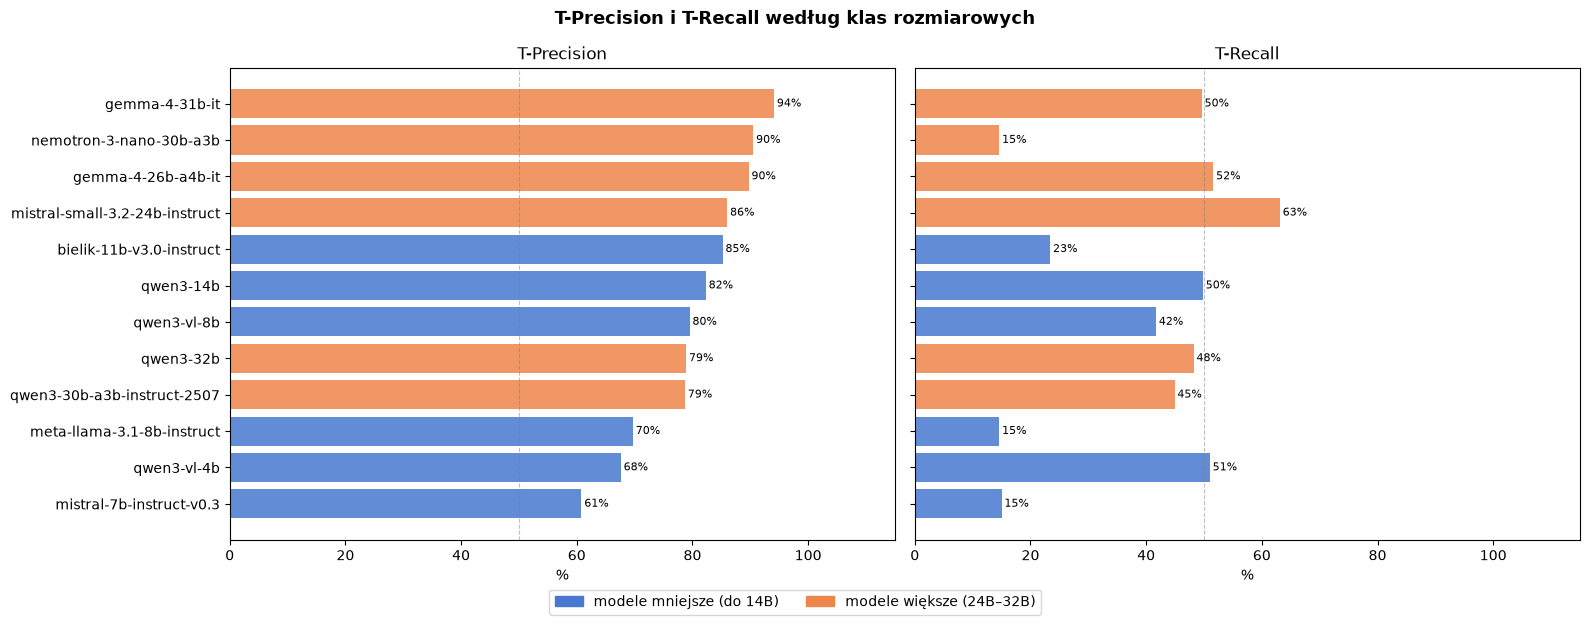

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model_order = summary.sort_values("t_precision", ascending=False)["model_short"].tolist()
etap_color_map = {
    "Etap 1 (4B–14B)": "#4878d0",
    "Etap 2 (24B–32B)": "#ee854a",
}

# Praca odeszla od nazewnictwa "Etap 1 / Etap 2" na rzecz klas
# rozmiarowych (podrozdzial 4.5.2). Kluczy ponizej nie zmieniamy, bo
# sluza do wyszukiwania koloru po kolumnie summary["etap"] - tlumaczymy
# je dopiero przy budowie legendy.
NAZWY_LEGENDY = {
    "Etap 1 (4B\u201314B)": "modele mniejsze (do 14B)",
    "Etap 2 (24B\u201332B)": "modele wi\u0119ksze (24B\u201332B)",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, metric, label in zip(axes, ["t_precision", "t_recall"], ["T-Precision", "T-Recall"]):
    vals = summary.set_index("model_short").reindex(model_order)
    colors = [etap_color_map[e] for e in vals["etap"]]
    bars = ax.barh(model_order[::-1], vals[metric][::-1] * 100, color=colors[::-1], alpha=0.85)
    for bar, val in zip(bars, vals[metric][::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val*100:.0f}%", va="center", fontsize=8)
    ax.set_xlim(0, 115)
    ax.set_xlabel("%")
    ax.set_title(label)
    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

patches = [mpatches.Patch(color=c, label=NAZWY_LEGENDY.get(e, e))
           for e, c in etap_color_map.items()]
fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("T-Precision i T-Recall według klas rozmiarowych", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Wykres: scatter T-Precision vs T-Recall

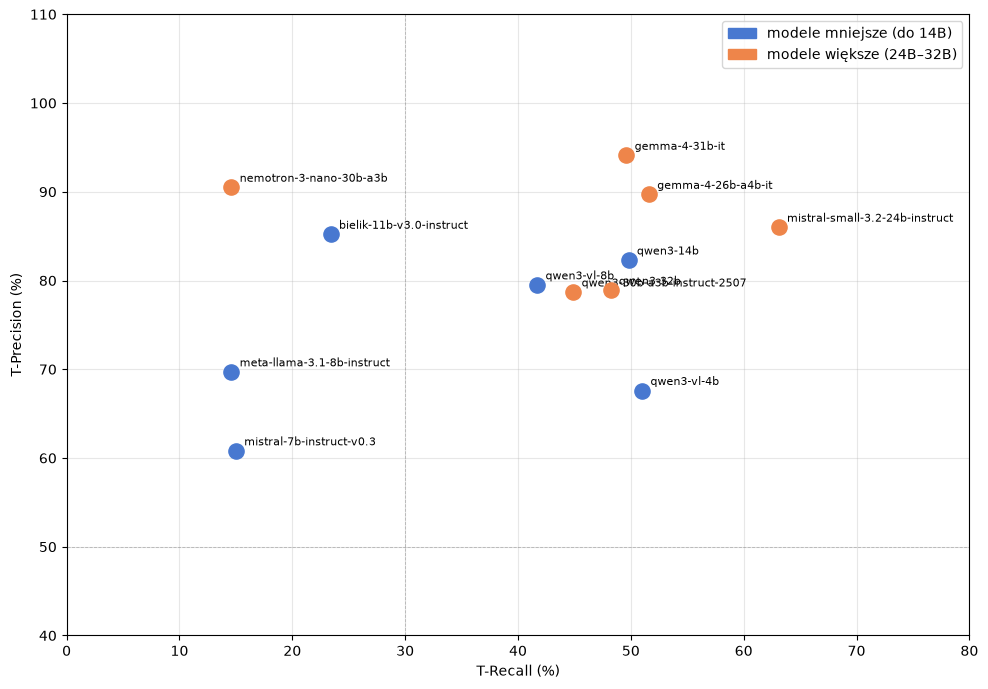

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in summary.iterrows():
    color = etap_color_map[row["etap"]]
    ax.scatter(row["t_recall"] * 100, row["t_precision"] * 100, color=color, s=120, zorder=3)
    ax.annotate(row["model_short"], (row["t_recall"] * 100, row["t_precision"] * 100),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("T-Recall (%)")
ax.set_ylabel("T-Precision (%)")
ax.set_xlim(0, 80)
ax.set_ylim(40, 110)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
ax.axvline(30, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
# ax.set_title("T-Precision vs T-Recall — Etap 1 (niebieski) vs Etap 2 (pomarańczowy)")
ax.grid(True, alpha=0.3)
patches = [mpatches.Patch(color=c, label=NAZWY_LEGENDY.get(e, e))
           for e, c in etap_color_map.items()]
ax.legend(handles=patches)
fig.tight_layout()
plt.show()

## Pełna tabela wyników (per artykuł)

In [26]:
display_cols = ["etap", "model_short", "title_short", "precision", "recall", "hall", "miss",
                "t_precision", "t_recall", "t_hall", "t_miss", "connectivity"]

rename_map = {
    "etap": "Etap", "model_short": "Model", "title_short": "Artykuł",
    "precision": "Prec.", "recall": "Recall",
    "hall": "Hall.", "miss": "Miss.",
    "t_precision": "T-Prec.", "t_recall": "T-Recall",
    "t_hall": "T-Hall.", "t_miss": "T-Miss.",
    "connectivity": "Connect.",
}

for article, group in df.groupby("title_short"):
    display(HTML(f"<h3>{article}</h3>"))
    styled = (
        group[display_cols]
        .sort_values("precision", ascending=False)
        .rename(columns=rename_map)
        .style
        .apply(color_etap, axis=1)
        .background_gradient(subset=["Prec.", "Recall", "T-Prec.", "T-Recall"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Connect."], cmap="Blues", vmin=0, vmax=1)
        .format({
            "Prec.": "{:.1%}", "Recall": "{:.1%}",
            "T-Prec.": "{:.1%}", "T-Recall": "{:.1%}",
            "Connect.": "{:.3f}",
        })
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )
    display(styled)

Etap,Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
Etap 1 (4B–14B),bielik-11b-v3.0-instruct,Langer serial SkyShowtime,100.0%,46.2%,0 | 12,14 | 26,100.0%,18.2%,0 | 12,54 | 66,0.857
Etap 1 (4B–14B),meta-llama-3.1-8b-instruct,Langer serial SkyShowtime,100.0%,45.2%,0 | 14,17 | 31,92.9%,19.7%,1 | 14,53 | 66,1.000
Etap 2 (24B–32B),nemotron-3-nano-30b-a3b,Langer serial SkyShowtime,100.0%,53.6%,0 | 15,13 | 28,100.0%,22.7%,0 | 15,51 | 66,0.348
Etap 2 (24B–32B),mistral-small-3.2-24b-instruct,Langer serial SkyShowtime,97.9%,64.8%,1 | 47,25 | 71,93.6%,66.7%,3 | 47,22 | 66,1.000
Etap 1 (4B–14B),qwen3-vl-8b,Langer serial SkyShowtime,96.8%,62.5%,1 | 31,18 | 48,77.4%,36.4%,7 | 31,42 | 66,0.938
Etap 2 (24B–32B),gemma-4-26b-a4b-it,Langer serial SkyShowtime,95.8%,56.1%,1 | 24,18 | 41,95.8%,34.8%,1 | 24,43 | 66,1.000
Etap 2 (24B–32B),gemma-4-31b-it,Langer serial SkyShowtime,90.9%,62.5%,2 | 22,12 | 32,100.0%,33.3%,0 | 22,44 | 66,1.000
Etap 1 (4B–14B),mistral-7b-instruct-v0.3,Langer serial SkyShowtime,90.9%,55.6%,2 | 22,16 | 36,59.1%,19.7%,9 | 22,53 | 66,0.281
Etap 2 (24B–32B),qwen3-30b-a3b-instruct-2507,Langer serial SkyShowtime,80.0%,48.8%,5 | 25,21 | 41,96.0%,36.4%,1 | 25,42 | 66,0.786
Etap 2 (24B–32B),qwen3-32b,Langer serial SkyShowtime,75.0%,63.8%,10 | 40,17 | 47,90.0%,54.5%,4 | 40,30 | 66,1.000


Etap,Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
Etap 1 (4B–14B),mistral-7b-instruct-v0.3,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,45.5%,0 | 10,12 | 22,40.0%,11.1%,6 | 10,32 | 36,0.833
Etap 2 (24B–32B),gemma-4-31b-it,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,71.0%,0 | 22,9 | 31,90.9%,55.6%,2 | 22,16 | 36,1.000
Etap 2 (24B–32B),nemotron-3-nano-30b-a3b,The Last of Us odcinek 5 tworcy o szokujacych scenach,100.0%,38.9%,0 | 7,11 | 18,71.4%,13.9%,2 | 7,31 | 36,0.500
Etap 1 (4B–14B),qwen3-14b,The Last of Us odcinek 5 tworcy o szokujacych scenach,95.7%,66.7%,1 | 23,11 | 33,82.6%,52.8%,4 | 23,17 | 36,0.407
Etap 2 (24B–32B),qwen3-30b-a3b-instruct-2507,The Last of Us odcinek 5 tworcy o szokujacych scenach,92.1%,79.5%,3 | 38,9 | 44,55.3%,58.3%,17 | 38,15 | 36,0.872
Etap 1 (4B–14B),qwen3-vl-4b,The Last of Us odcinek 5 tworcy o szokujacych scenach,92.0%,67.6%,2 | 25,11 | 34,68.0%,47.2%,8 | 25,19 | 36,0.278
Etap 2 (24B–32B),gemma-4-26b-a4b-it,The Last of Us odcinek 5 tworcy o szokujacych scenach,86.4%,63.3%,3 | 22,11 | 30,86.4%,52.8%,3 | 22,17 | 36,0.905
Etap 1 (4B–14B),bielik-11b-v3.0-instruct,The Last of Us odcinek 5 tworcy o szokujacych scenach,84.6%,52.4%,2 | 13,10 | 21,69.2%,25.0%,4 | 13,27 | 36,0.077
Etap 1 (4B–14B),qwen3-vl-8b,The Last of Us odcinek 5 tworcy o szokujacych scenach,81.8%,56.2%,4 | 22,14 | 32,81.8%,50.0%,4 | 22,18 | 36,0.182
Etap 2 (24B–32B),mistral-small-3.2-24b-instruct,The Last of Us odcinek 5 tworcy o szokujacych scenach,77.8%,63.6%,6 | 27,12 | 33,77.8%,58.3%,6 | 27,15 | 36,0.429


Etap,Model,Artykuł,Prec.,Recall,Hall.,Miss.,T-Prec.,T-Recall,T-Hall.,T-Miss.,Connect.
Etap 1 (4B–14B),bielik-11b-v3.0-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,44.9%,0 | 22,27 | 49,86.4%,27.1%,3 | 22,51 | 70,0.917
Etap 2 (24B–32B),nemotron-3-nano-30b-a3b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,22.7%,0 | 5,17 | 22,100.0%,7.1%,0 | 5,65 | 70,0.714
Etap 2 (24B–32B),mistral-small-3.2-24b-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,78.8%,0 | 52,14 | 66,86.5%,64.3%,7 | 52,25 | 70,0.849
Etap 2 (24B–32B),gemma-4-31b-it,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,100.0%,76.7%,0 | 46,14 | 60,91.3%,60.0%,4 | 46,28 | 70,1.000
Etap 2 (24B–32B),qwen3-30b-a3b-instruct-2507,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,93.9%,53.4%,2 | 33,27 | 58,84.8%,40.0%,5 | 33,42 | 70,0.882
Etap 1 (4B–14B),meta-llama-3.1-8b-instruct,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,93.3%,48.3%,1 | 15,15 | 29,73.3%,15.7%,4 | 15,59 | 70,1.000
Etap 2 (24B–32B),qwen3-32b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,92.5%,60.7%,3 | 40,24 | 61,80.0%,45.7%,8 | 40,38 | 70,1.000
Etap 1 (4B–14B),mistral-7b-instruct-v0.3,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,91.7%,32.4%,1 | 12,23 | 34,83.3%,14.3%,2 | 12,60 | 70,0.600
Etap 2 (24B–32B),gemma-4-26b-a4b-it,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,90.7%,79.0%,5 | 54,13 | 62,87.0%,67.1%,7 | 54,23 | 70,0.855
Etap 1 (4B–14B),qwen3-14b,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,90.2%,67.3%,4 | 41,18 | 55,97.6%,57.1%,1 | 41,30 | 70,0.800


## F1 i T-F1 — ranking wszystkich modeli

In [27]:
def f1(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0

ranking_base = summary.copy()
ranking_base["F1"] = ranking_base.apply(lambda r: f1(r["precision"], r["recall"]), axis=1).round(3)
ranking_base["T-F1"] = ranking_base.apply(lambda r: f1(r["t_precision"], r["t_recall"]), axis=1).round(3)

cols_show = ["model_short", "etap", "precision", "recall", "F1", "t_precision", "t_recall", "T-F1"]
rename_rank = {"model_short": "Model", "etap": "Etap",
               "precision": "Prec.", "recall": "Recall",
               "t_precision": "T-Prec.", "t_recall": "T-Recall"}
fmt = {c: "{:.1%}" for c in ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]}
grad_cols = ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]

for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    ranking = ranking_base.sort_values(sort_col, ascending=False)
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>"))
    display(
        ranking[cols_show]
        .rename(columns=rename_rank)
        .style
        .apply(color_etap, axis=1)
        .background_gradient(subset=grad_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format(fmt)
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )

Model,Etap,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
nemotron-3-nano-30b-a3b,Etap 2 (24B–32B),100.0%,38.4%,55.5%,90.5%,14.6%,25.1%
gemma-4-31b-it,Etap 2 (24B–32B),97.0%,70.1%,81.4%,94.1%,49.6%,65.0%
bielik-11b-v3.0-instruct,Etap 1 (4B–14B),94.9%,47.8%,63.6%,85.2%,23.4%,36.7%
mistral-7b-instruct-v0.3,Etap 1 (4B–14B),94.2%,44.5%,60.4%,60.8%,15.0%,24.1%
mistral-small-3.2-24b-instruct,Etap 2 (24B–32B),91.9%,69.1%,78.9%,86.0%,63.1%,72.8%
gemma-4-26b-a4b-it,Etap 2 (24B–32B),91.0%,66.1%,76.6%,89.7%,51.6%,65.5%
qwen3-30b-a3b-instruct-2507,Etap 2 (24B–32B),88.7%,60.6%,72.0%,78.7%,44.9%,57.2%
qwen3-vl-8b,Etap 1 (4B–14B),88.0%,56.8%,69.0%,79.5%,41.7%,54.7%
qwen3-14b,Etap 1 (4B–14B),81.6%,60.6%,69.5%,82.3%,49.8%,62.1%
qwen3-32b,Etap 2 (24B–32B),79.4%,58.7%,67.5%,78.9%,48.2%,59.8%


Model,Etap,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,Etap 2 (24B–32B),97.0%,70.1%,81.4%,94.1%,49.6%,65.0%
nemotron-3-nano-30b-a3b,Etap 2 (24B–32B),100.0%,38.4%,55.5%,90.5%,14.6%,25.1%
gemma-4-26b-a4b-it,Etap 2 (24B–32B),91.0%,66.1%,76.6%,89.7%,51.6%,65.5%
mistral-small-3.2-24b-instruct,Etap 2 (24B–32B),91.9%,69.1%,78.9%,86.0%,63.1%,72.8%
bielik-11b-v3.0-instruct,Etap 1 (4B–14B),94.9%,47.8%,63.6%,85.2%,23.4%,36.7%
qwen3-14b,Etap 1 (4B–14B),81.6%,60.6%,69.5%,82.3%,49.8%,62.1%
qwen3-vl-8b,Etap 1 (4B–14B),88.0%,56.8%,69.0%,79.5%,41.7%,54.7%
qwen3-32b,Etap 2 (24B–32B),79.4%,58.7%,67.5%,78.9%,48.2%,59.8%
qwen3-30b-a3b-instruct-2507,Etap 2 (24B–32B),88.7%,60.6%,72.0%,78.7%,44.9%,57.2%
meta-llama-3.1-8b-instruct,Etap 1 (4B–14B),74.0%,35.3%,47.8%,69.7%,14.6%,24.1%


## Etap 1 vs Etap 2 — średnie grupy

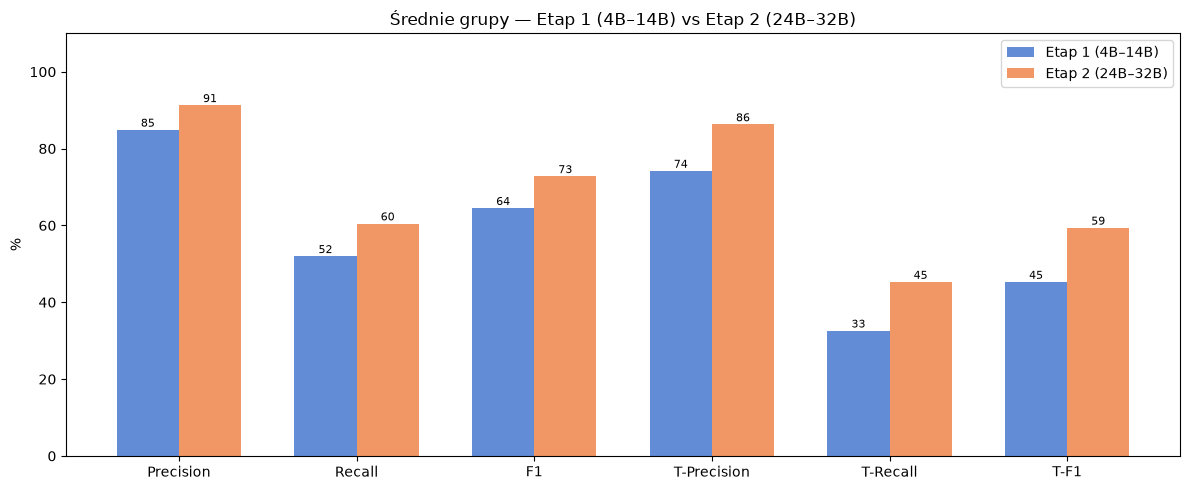

,Precision,Recall,F1,T-Precision,T-Recall,T-F1
etap,,,,,,
Etap 1 (4B–14B),84.9%,52.0%,64.5%,74.2%,32.6%,45.3%
Etap 2 (24B–32B),91.3%,60.5%,72.8%,86.3%,45.3%,59.4%


In [28]:
etap_avg = df.groupby("etap")[NUMERIC].mean().round(3)
etap_avg["f1"] = etap_avg.apply(lambda r: f1(r["precision"], r["recall"]), axis=1).round(3)
etap_avg["t_f1"] = etap_avg.apply(lambda r: f1(r["t_precision"], r["t_recall"]), axis=1).round(3)

metrics_plot = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1"]
labels_plot  = ["Precision", "Recall", "F1", "T-Precision", "T-Recall", "T-F1"]

x = np.arange(len(metrics_plot))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
for i, (etap, row) in enumerate(etap_avg.iterrows()):
    color = list(etap_color_map.values())[i]
    bars = ax.bar(x + (i - 0.5) * w, [row[m] * 100 for m in metrics_plot], w,
                  label=etap, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{bar.get_height():.0f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.set_title("Średnie grupy — Etap 1 (4B–14B) vs Etap 2 (24B–32B)")
ax.legend()
fig.tight_layout()
plt.show()

display(etap_avg[metrics_plot]
    .rename(columns=dict(zip(metrics_plot, labels_plot)))
    .style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    .format("{:.1%}"))

## Najlepszy model per artykuł × metryka

In [29]:
winners = {}
for metric in ["precision", "recall", "t_precision", "t_recall"]:
    idx = df.groupby("title_short")[metric].idxmax()
    winners[metric] = df.loc[idx].set_index("title_short")["model_short"]

winners_df = pd.DataFrame(winners).rename(columns={
    "precision": "Prec.", "recall": "Recall",
    "t_precision": "T-Prec.", "t_recall": "T-Recall"
})
display(HTML("<p>Najlepszy model per artykuł per metryka:</p>"))
display(winners_df.style.set_table_styles([
    {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 12px")]},
    {"selector": "th", "props": [("white-space", "nowrap")]},
]))

,Prec.,Recall,T-Prec.,T-Recall
title_short,,,,
Langer serial SkyShowtime,bielik-11b-v3.0-instruct,qwen3-vl-4b,bielik-11b-v3.0-instruct,mistral-small-3.2-24b-instruct
The Last of Us odcinek 5 tworcy o szokujacych scenach,mistral-7b-instruct-v0.3,qwen3-30b-a3b-instruct-2507,gemma-4-31b-it,mistral-small-3.2-24b-instruct
Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,bielik-11b-v3.0-instruct,gemma-4-26b-a4b-it,nemotron-3-nano-30b-a3b,gemma-4-26b-a4b-it


## Heatmapa halucynacji: unsupported / total relations

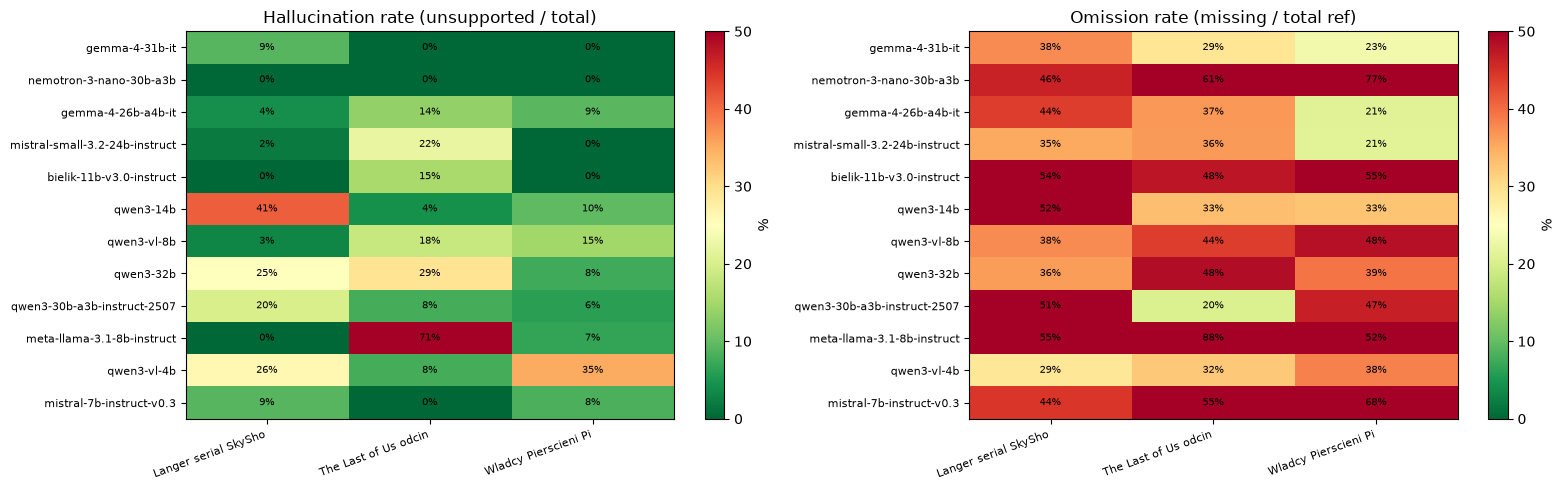

In [30]:
def parse_hall_rate(s):
    try:
        unsup, total = s.split("|")
        return int(unsup.strip()) / int(total.strip())
    except:
        return float("nan")

df["hall_rate"] = df["hall"].apply(parse_hall_rate)
df["miss_rate"] = df["miss"].apply(lambda s: parse_hall_rate(s))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_order_all = ranking["model_short"].tolist()

for ax, col, title in zip(axes,
                           ["hall_rate", "miss_rate"],
                           ["Hallucination rate (unsupported / total)", "Omission rate (missing / total ref)"]):
    pivot = df.pivot_table(index="model_short", columns="title_short", values=col).reindex(model_order_all) * 100
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0, vmax=50, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([c[:20] for c in pivot.columns], rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="%")
    ax.set_title(title)

fig.tight_layout()
plt.show()

  Ogólna przewaga Etapu 2

  Większe modele wypadają lepiej na wszystkich metrykach. Średnia grupy Etap 2 vs Etap 1: Precision +6 pp (0.913 vs 0.850), Recall +8 pp (0.605 vs 0.520), T-Precision +12 pp (0.863
  vs 0.742), T-Recall +13 pp (0.453 vs 0.326). Różnica jest szczególnie wyraźna w T-metrykach — większe modele znacznie lepiej pokrywają semantykę grafu referencyjnego.

  Najlepsze modele ogółem

  Mistral-small-24b osiąga najwyższy T-F1 (0.728) dzięki najlepszemu balansowi T-Precision (0.860) i T-Recall (0.631). Gemma-4-31b ma najwyższą T-Precision (0.941) ale niższy
  T-Recall (0.496), przez co T-F1 spada do 0.650. Jeśli ważniejsza jest dokładność ekstrakcji — gemma-4-31b, jeśli kompletność — mistral-small-24b.

  Rozmiar modelu nie zawsze ma znaczenie

  Qwen3-14b (Etap 1, 14B) osiąga T-F1 = 0.621, co przewyższa qwen3-30b (0.572) i qwen3-32b (0.598) z Etapu 2. To sugeruje, że architektura i trening mają większe znaczenie niż sama
  liczba parametrów — modele Qwen3 w wariancie 32B nie skalują się liniowo względem 14B.

  Precision vs T-Precision — różne rankingi

  Sortowanie po Precision stawia na szczycie nemotron-30b (1.000) i bielik-11b (0.949), ale po T-Precision wygrywają gemma-4-31b (0.941) i nemotron-30b (0.905). Nemotron to skrajny
  przykład: ekstraktuje bardzo mało relacji (Recall 0.384, T-Recall 0.146) ale każda jest niemal bezbłędna — model jest ultra-konserwatywny. Wysoka Precision bez wysokiego Recall
  jest łatwa do osiągnięcia przez pomijanie niepewnych relacji, dlatego T-F1 jest lepszą miarą ogólnej jakości.

  Anomalie

  Nemotron-30b przy 30B parametrach wypada gorzej niż qwen3-14b w T-F1 (0.251 vs 0.621) — model praktycznie nie ekstraktoruje grafu. Mistral-7b (Etap 1) ma Precision 0.942, ale
  T-Precision tylko 0.608 — relacje są wyrażone inaczej niż w referencji, co świadczy o słabym rozumieniu semantycznym mimo formalnej poprawności zapisu

## Selekcja 8 modeli do dalszych badań

In [31]:
SELECTED = {
    "mistral-small-3.2-24b-instruct": "najlepszy T-F1 (0.728), najlepszy balans",
    "gemma-4-31b-it":                 "najwyższa T-Precision (0.941)",
    "gemma-4-26b-a4b-it":             "para dla 31b, skalowanie Gemma",
    "qwen3-32b":                       "duży Qwen, dense model",
    "qwen3-30b-a3b-instruct-2507":    "MoE — inna architektura niż dense 32b",
    "qwen3-14b":                       "najlepszy mały model, bije qwen3-30b/32b w T-F1",
    "bielik-11b-v3.0-instruct":       "jedyny polski model, kluczowy dla tezy",
    "qwen3-vl-8b":                     "solidny mid-range, skalowanie Qwen (8B→14B→32B)",
}

DROPPED = {
    "nemotron-3-nano-30b-a3b":        "T-F1=0.251, T-Recall=0.146 — praktycznie nie ekstraktoruje grafu",
    "meta-llama-3.1-8b-instruct":     "najsłabszy T-F1 (0.241), najniższy Recall",
    "mistral-7b-instruct-v0.3":       "T-F1=0.241, słabe rozumienie semantyczne",
    "qwen3-vl-4b":                     "4B zbędne przy obecności 8b-sibling (niższa T-Precision)",
}

sel_df = (
    ranking_base[ranking_base["model_short"].isin(SELECTED)]
    .sort_values("T-F1", ascending=False)
    .assign(Uzasadnienie=lambda d: d["model_short"].map(SELECTED))
)

drop_df = (
    ranking_base[ranking_base["model_short"].isin(DROPPED)]
    .sort_values("T-F1", ascending=False)
    .assign(Uzasadnienie=lambda d: d["model_short"].map(DROPPED))
)

cols = ["model_short", "etap", "precision", "recall", "F1", "t_precision", "t_recall", "T-F1", "Uzasadnienie"]
rename = {"model_short": "Model", "etap": "Etap",
          "precision": "Prec.", "recall": "Recall",
          "t_precision": "T-Prec.", "t_recall": "T-Recall"}
fmt = {c: "{:.1%}" for c in ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]}
grad = ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]
tbl_style = [
    {"selector": "th", "props": [("white-space", "nowrap")]},
    {"selector": "td:last-child", "props": [("text-align", "left"), ("font-size", "12px"), ("color", "#555")]},
]

display(HTML("<h4>✅ Wybrane modele (8)</h4>"))
display(
    sel_df[cols].rename(columns=rename).style
    .apply(color_etap, axis=1)
    .background_gradient(subset=grad, cmap="RdYlGn", vmin=0, vmax=1)
    .format(fmt)
    .set_table_styles(tbl_style)
    .hide(axis="index")
)

display(HTML("<h4>❌ Odrzucone modele (4)</h4>"))
display(
    drop_df[cols].rename(columns=rename).style
    .apply(color_etap, axis=1)
    .background_gradient(subset=grad, cmap="RdYlGn", vmin=0, vmax=1)
    .format(fmt)
    .set_table_styles(tbl_style)
    .hide(axis="index")
)

Model,Etap,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1,Uzasadnienie
mistral-small-3.2-24b-instruct,Etap 2 (24B–32B),91.9%,69.1%,78.9%,86.0%,63.1%,72.8%,"najlepszy T-F1 (0.728), najlepszy balans"
gemma-4-26b-a4b-it,Etap 2 (24B–32B),91.0%,66.1%,76.6%,89.7%,51.6%,65.5%,"para dla 31b, skalowanie Gemma"
gemma-4-31b-it,Etap 2 (24B–32B),97.0%,70.1%,81.4%,94.1%,49.6%,65.0%,najwyższa T-Precision (0.941)
qwen3-14b,Etap 1 (4B–14B),81.6%,60.6%,69.5%,82.3%,49.8%,62.1%,"najlepszy mały model, bije qwen3-30b/32b w T-F1"
qwen3-32b,Etap 2 (24B–32B),79.4%,58.7%,67.5%,78.9%,48.2%,59.8%,"duży Qwen, dense model"
qwen3-30b-a3b-instruct-2507,Etap 2 (24B–32B),88.7%,60.6%,72.0%,78.7%,44.9%,57.2%,MoE — inna architektura niż dense 32b
qwen3-vl-8b,Etap 1 (4B–14B),88.0%,56.8%,69.0%,79.5%,41.7%,54.7%,"solidny mid-range, skalowanie Qwen (8B→14B→32B)"
bielik-11b-v3.0-instruct,Etap 1 (4B–14B),94.9%,47.8%,63.6%,85.2%,23.4%,36.7%,"jedyny polski model, kluczowy dla tezy"


Model,Etap,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1,Uzasadnienie
qwen3-vl-4b,Etap 1 (4B–14B),77.0%,66.8%,71.5%,67.6%,51.0%,58.1%,4B zbędne przy obecności 8b-sibling (niższa T-Precision)
nemotron-3-nano-30b-a3b,Etap 2 (24B–32B),100.0%,38.4%,55.5%,90.5%,14.6%,25.1%,"T-F1=0.251, T-Recall=0.146 — praktycznie nie ekstraktoruje grafu"
mistral-7b-instruct-v0.3,Etap 1 (4B–14B),94.2%,44.5%,60.4%,60.8%,15.0%,24.1%,"T-F1=0.241, słabe rozumienie semantyczne"
meta-llama-3.1-8b-instruct,Etap 1 (4B–14B),74.0%,35.3%,47.8%,69.7%,14.6%,24.1%,"najsłabszy T-F1 (0.241), najniższy Recall"
